<a href="https://colab.research.google.com/github/eklavya0948-max/electric-load-forecasting-weather-time/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is linear regression?
Linear regression is model type which is used to relate one independent variable lets say X which is our input value to an dependent variable lets say Y which is output of model in a straight line to predict a continious target varaible from a dataset.

In this project, Linear Regression is used to predict electrical load using
meteorological and time-based factors such as temperature, humidity, hour,
day of week, and month.


import cleaned dataset


In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned data.csv to cleaned data.csv


In [3]:
# To load data
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned data.csv")
# To view data
df.head()

,datetime,temperature,humidity,load,hour,day_of_week,month
0,2021-01-01 01:00:00,65,90,1967.388015,1,4,1
1,2021-01-01 02:00:00,65,90,1967.388015,2,4,1
2,2021-01-01 03:00:00,65,90,1967.388015,3,4,1
3,2021-01-01 04:00:00,78,49,2442.607331,4,4,1
4,2021-01-01 05:00:00,78,49,2756.205522,5,4,1


To define features and load

In [4]:
# X(input): features
# Y(output): load
X = df[["temperature","humidity","hour","day_of_week","month"]]
y = df["load"]

Training test split

Using 80% dataset for training and 20% for testing . You can change training dataset by  changing test size.


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Linear Regression model


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Making Predictions


In [7]:
y_pred = model.predict(X_test)

Evaluating model using 2 statistical tools

1. MAE( Mean Absolute Error)

  It measures average size of error

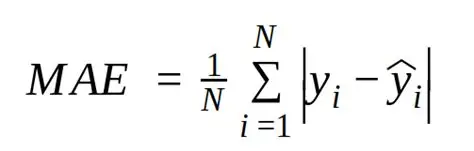

Here ,


 $y_i$= actual value

 $\hat{y}_i$= predicted value

 N= No. of data ppints

 2. RMSE ( Root Mean Squared Error )


RMSE calculates the square root of the average of squared differences between predicted and actual values.

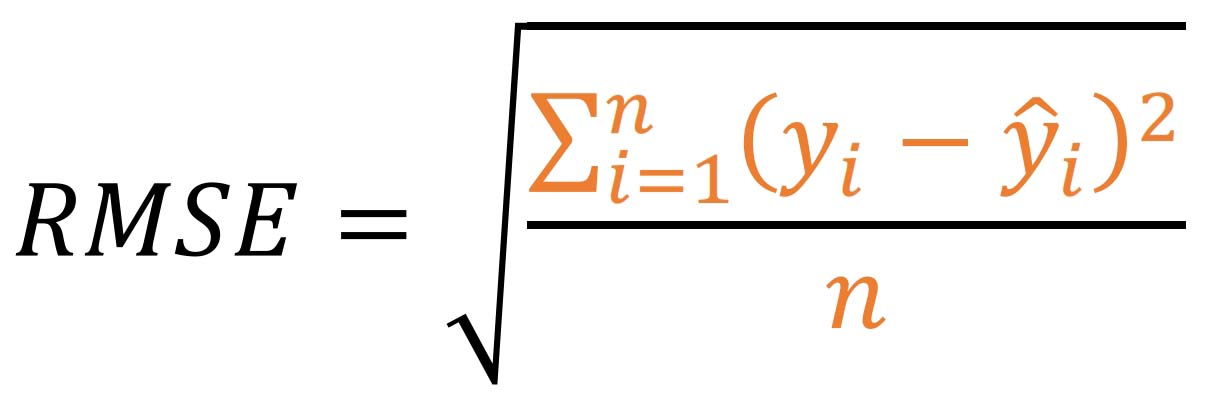




In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 943.6779789206221
RMSE: 1161.4329101633457


Plotting Actual vs Predicted load graph

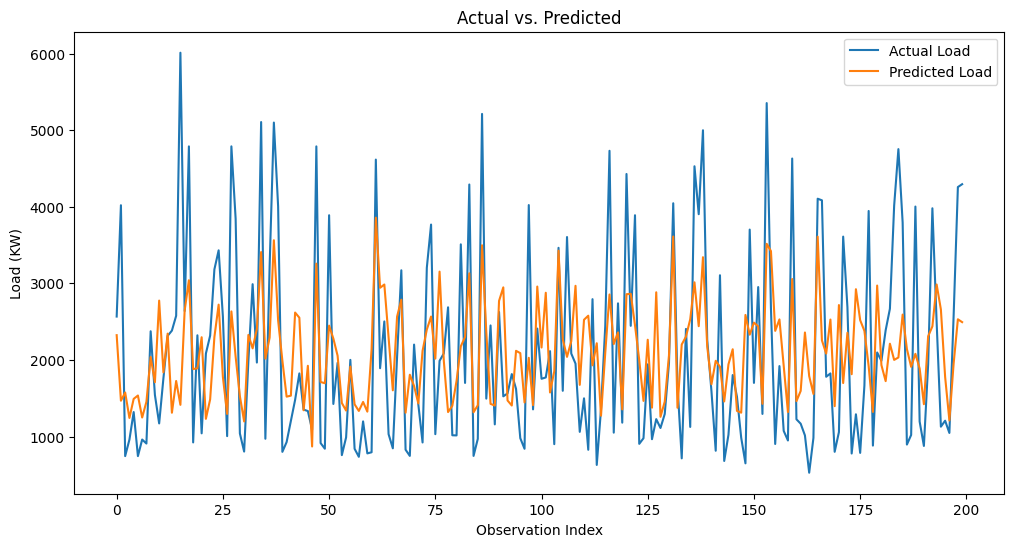

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label="Actual Load")
plt.plot(y_pred[:200], label="Predicted Load")

plt.legend()
plt.title("Actual vs. Predicted")
plt.xlabel("Observation Index")
plt.ylabel("Load (KW)")
plt.savefig('actual vs predicted.png') # Saving the graph
plt.show()

Our maximum approx. load value was 6306 KW . Our MAE result means that our average predicted value is 944 KW more or 944 KW less than the actual value . Our RMSE > MAE which tells that there is large error in prediction since it punishes large error harshly. If we calculate percentage error of MAE with respect to maximum load it will be

       ( 944 / 6306 ) * 100 = 14.97 %

If we calculate for RMSE we get percentage error

      ( 1161.5 / 6306 ) * 100 = 18.42 %

Which are quiet big error and can cause us loss of electrical equipments.

Temprature VS Actual Load graph

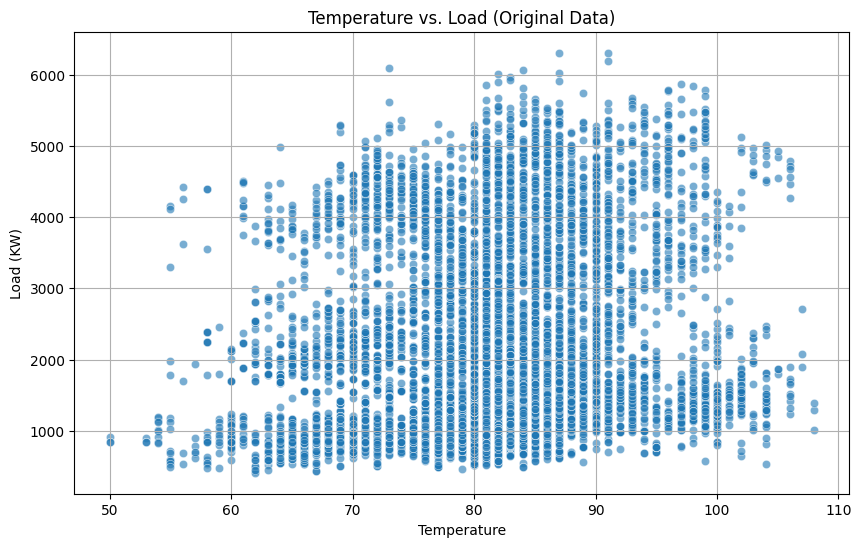

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['temperature'], y=df['load'], alpha=0.6)
plt.title('Temperature vs. Load (Original Data)')
plt.xlabel('Temperature')
plt.ylabel('Load (KW)')
plt.grid(True)
plt.savefig('temperature vs load.png') # Saving the graph
plt.show()

Temprature VS Predicted Load graph

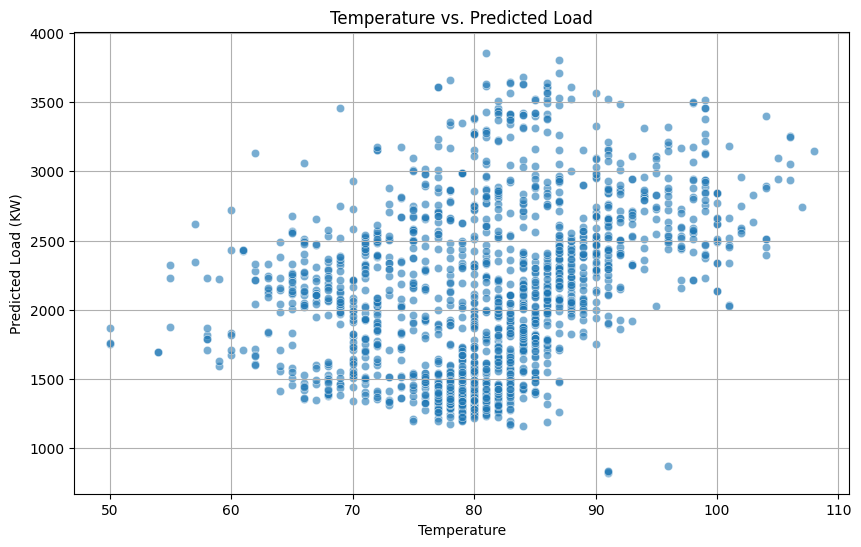

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['temperature'], y=y_pred, alpha=0.6)
plt.title('Temperature vs. Predicted Load')
plt.xlabel('Temperature')
plt.ylabel('Predicted Load (KW)')
plt.grid(True)
plt.savefig('temperature vs predictedload.png') # Saving the graph
plt.show()

So lets try to increase our accuracy of model . We know that load follows certain patterns like repeating itself pereodicaly . So lets add lag features so that our model can learn past patterns of electricity consumptions. Basically we are adding a type of memory to linear regression to remember patterns of lad consumption.

In [22]:
# What are lag features?
# Lag features are previous time step values used as input features in a model.
# They help the model understand how past electricity load affects the current load.

# What is a time step in lag features?
# A time step refers to the interval between two data points.
# In this project the time step is one hour, meaning the load is recorded every hour.

# Example:
# lag_1 means load from previous hour
# lag_2 means load from 2 hours ago
# lag_7 means load from 7 hours ago
# lag_24 -> load from the same hour on the previous day

df["load_lag1"] = df["load"].shift(1)
df["load_lag2"] = df["load"].shift(2)
df["load_lag3"] = df["load"].shift(3)
df["load_lag6"] = df["load"].shift(6)
df["load_lag12"] = df["load"].shift(12)
df["load_lag24"] = df["load"].shift(24)
df["load_lag48"] = df["load"].shift(48)
df["load_lag168"] = df["load"].shift(168)

To handle missing values

In [23]:
df = df.dropna()

Redefining X and Y

In [24]:
X = df[['temperature',
        'humidity',
        'hour',
        'day_of_week',
        'month',
        'load_lag1',
        'load_lag2',
        'load_lag3',
        'load_lag6',
        'load_lag12',
        'load_lag24',
        'load_lag48',
        'load_lag168']]

y = df['load']

Retraining model with newly defined features

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

Evaluating new model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 244.4846045039508
RMSE: 398.19501469100356


Our new MAE and RMSE results are clearly far low than are previous value which a huge leap in our model accuracy. Low RMSE shows that there isnt any large error in predicted data.

Our percentage MAE error with max load is also reduced

        ( 244.5 / 6306 ) * 100 = 3.88 %

Same goes with our Percentage RMSE error with maximum load

        ( 398.2 / 6303 ) * 100 = 6.31 %

Which is quite good accuracy for linear regression model computing non linear complex electric load



Plotting improved models actual vs predicted graph.

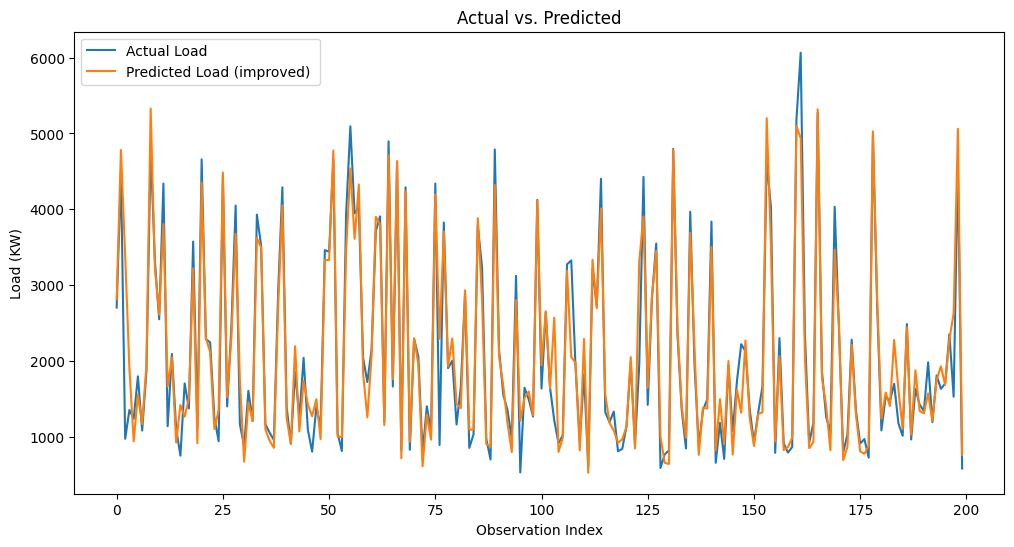

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label="Actual Load")
plt.plot(y_pred[:200], label="Predicted Load (improved) ")

plt.legend()
plt.title("Actual vs. Predicted")
plt.xlabel("Observation Index")
plt.ylabel("Load (KW)")
plt.savefig('actual vs predicted (improved).png') # Saving the graph
plt.show()

Plotting Temprature VS Predicted Load (improved)






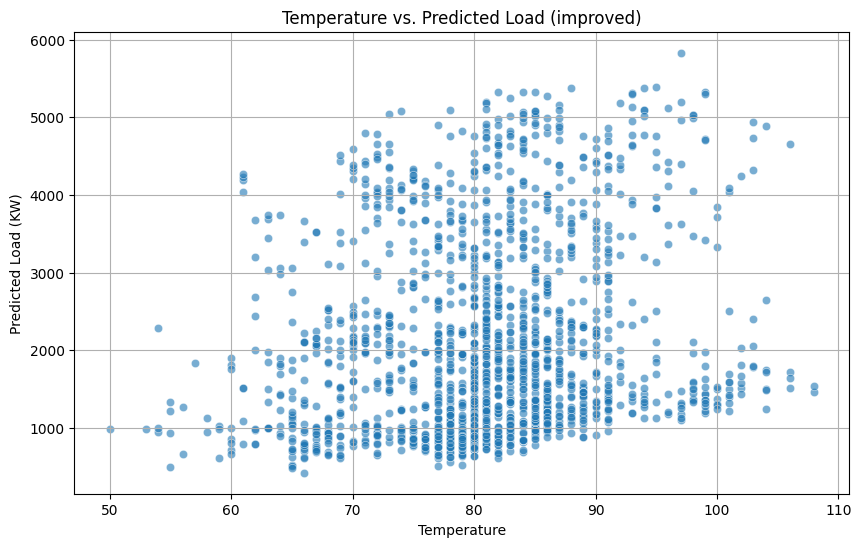

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['temperature'], y=y_pred, alpha=0.6)
plt.title('Temperature vs. Predicted Load (improved)')
plt.xlabel('Temperature')
plt.ylabel('Predicted Load (KW)')
plt.grid(True)
plt.savefig('temperature vs predictedload(Improved).png') # Saving the graph
plt.show()